# Experiment — LSTM + attention with focal loss (discarded)

`LSTMAttentionBinary` trained with a custom `FocalLoss`, the idea being that focal loss would help on the strongly under-represented `high_pain` class.

It did not: on a dataset this small focal loss amplified label noise and destabilised optimisation. The final models use class-weighted cross-entropy with label smoothing instead. This is the experiment described in section 4 of the report.

---


## Google Drive Connection


In [ ]:
# --- Paths ---------------------------------------------------------------
# Originally executed on Google Colab with the dataset on Google Drive.
# DATA_DIR must contain: pirate_pain_train.csv, pirate_pain_train_labels.csv,
# pirate_pain_test.csv, sample_submission.csv  (see data/README.md)
import os

DATA_DIR = os.environ.get("PIRATE_DATA_DIR", "data")
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)


## Libraries Import


In [3]:
# @title
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, Dataset, DataLoader, WeightedRandomSampler
logs_dir = "tensorboard"
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

from sklearn.model_selection import StratifiedGroupKFold

import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

PyTorch version: 2.8.0+cu126
Device: cuda


## Exploration and Data Analysis


In [4]:
# Define the window size
WINDOW_SIZE = 200

# Define the stride for overlapping windows
STRIDE = 50

# Define the batch size
BATCH_SIZE = 64

KFOLD_SPLITS = 3

In [5]:
X_train = pd.read_csv('../Dataset/pirate_pain_train.csv')
y_train = pd.read_csv('../Dataset/pirate_pain_train_labels.csv')
X_test = pd.read_csv('../Dataset/pirate_pain_test.csv')

# Remove rows with any missing values
X_train.dropna(axis=0, how='any', inplace=True)
y_train.dropna(axis=0, how='any', inplace=True)
X_test.dropna(axis=0, how='any', inplace=True)

df_full = X_train.merge(y_train, on="sample_index")
df_full = df_full[df_full["label"] != "no_pain"]
X_train = df_full.drop(columns=["label"])
y_train = df_full[["sample_index", "label"]]

# Check for and drop columns with only one unique value
cols_to_drop = []
for col in X_train.columns:
  if X_train[col].nunique() == 1:
    print(f"Column '{col}' has only one unique value")
    cols_to_drop.append(col)

X_train = X_train.drop(columns=cols_to_drop)

# Check unique values in 'n_legs', 'n_hands', and 'n_eyes'
print("Unique values in 'n_legs':", X_train['n_legs'].unique())
print("Unique values in 'n_hands':", X_train['n_hands'].unique())
print("Unique values in 'n_eyes':", X_train['n_eyes'].unique())

# Define a mapping for string representations of strings to integers
legs_mapping = {
    'two': 2,
    'one+peg_leg': 1
}

hands_mapping = {
    'two': 2,
    'one+hook_hand': 1
}

eyes_mapping = {
    'two': 2,
    'one+eye_patch': 1
}

# Convert 'n_legs', 'n_hands', and 'n_eyes' to integers using the mapping
X_train['n_legs'] = X_train['n_legs'].map(legs_mapping)
X_train['n_hands'] = X_train['n_hands'].map(hands_mapping)
X_train['n_eyes'] = X_train['n_eyes'].map(eyes_mapping)

X_test['n_legs'] = X_test['n_legs'].map(legs_mapping)
X_test['n_hands'] = X_test['n_hands'].map(hands_mapping)
X_test['n_eyes'] = X_test['n_eyes'].map(eyes_mapping)

# Define a mapping of status names to integer labels
label_mapping = {
    'low_pain': 0,
    'high_pain': 1
}

# Map status names to integers in the labels set
y_train['label'] = y_train['label'].map(label_mapping)

# Convert 'joint_*' columns to float32 data type to use less memory
for col in X_train.columns:
  if 'joint' in col:
    X_train[col] = X_train[col].astype(np.float32)

for col in X_test.columns:
  if 'joint' in col:
    X_test[col] = X_test[col].astype(np.float32)

# StratifiedGroup Split
df_subjects = (X_train[['sample_index']]
    .drop_duplicates()
    .merge(y_train, on='sample_index')
)

sgkf = StratifiedGroupKFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(
    df_subjects,
    df_subjects['label'],
    groups=df_subjects['sample_index']
))

train_users = df_subjects.iloc[train_idx]['sample_index'].values
val_users   = df_subjects.iloc[val_idx]['sample_index'].values

df_train = X_train[X_train['sample_index'].isin(train_users)]
df_val   = X_train[X_train['sample_index'].isin(val_users)]

# Define the columns to be normalised
num_joints = 29
pain_survey_cols = [f'pain_survey_{i+1}' for i in range(4)]
joint_cols = [f'joint_{i:02d}' for i in range(num_joints + 1)]
dyn_cols = pain_survey_cols + joint_cols

means = df_train[dyn_cols].mean()
stds  = df_train[dyn_cols].std()

# Z-score normalization
for df in [df_train, df_val]:
    df[dyn_cols] = (df[dyn_cols] - means) / (stds + 1e-8)

Column 'joint_30' has only one unique value
Unique values in 'n_legs': ['two' 'one+peg_leg']
Unique values in 'n_hands': ['two' 'one+hook_hand']
Unique values in 'n_eyes': ['two' 'one+eye_patch']


In [6]:
import numpy as np

def augment_sequence(X_seq,
                     noise_std=0.01,
                     scale_sigma=0.05,
                     time_warp_sigma=0.05,
                     jitter_prob=0.05,
                     slice_ratio=0.9):
    """Data augmentation for multivariate time series (pirate joints + pain_survey).

    Args:
        X_seq (np.ndarray): Sequence (window, features)
        noise_std (float): Gaussian noise applied to joints
        scale_sigma (float): Magnitude scaling factor
        time_warp_sigma (float): Amount of time warping
        jitter_prob (float): Probability of adding noise per element
        slice_ratio (float): Fraction of the sequence to keep

    Returns:
        np.ndarray: Augmented sequence (window, features)
    """X_aug = X_seq.copy()
    window, n_features = X_aug.shape

    # Define columns
    pain_survey_cols = 4          # first 4 features are pain_survey
    joint_cols = n_features - pain_survey_cols

    # ------------------
    # Additive Gaussian Noise (joints only)
    # ------------------
    X_aug[:, pain_survey_cols:] += np.random.normal(0, noise_std, (window, joint_cols))

    # ------------------
    # Magnitude scaling (joints only)
    # ------------------
    factor = np.random.normal(1.0, scale_sigma)
    X_aug[:, pain_survey_cols:] *= factor

    # ------------------
    # Time warping (same for all features)
    # ------------------
    if time_warp_sigma > 0:
        tt = np.arange(window)
        tt_new = tt + np.random.normal(0, time_warp_sigma * window, size=window)
        tt_new = np.clip(tt_new, 0, window - 1)
        for i in range(n_features):
            X_aug[:, i] = np.interp(tt, tt_new, X_aug[:, i])

    # ------------------
    # Realistic jitter (joints only)
    # ------------------
    mask = np.random.rand(window, joint_cols) < jitter_prob
    X_aug[:, pain_survey_cols:][mask] += np.random.normal(0, noise_std, np.sum(mask))

    # ------------------
    # Random window slicing
    # ------------------
    if slice_ratio < 1.0:
        new_len = int(window * slice_ratio)
        start_idx = np.random.randint(0, window - new_len + 1)
        X_aug = X_aug[start_idx:start_idx + new_len]
        # Pad back to original length using edge values
        if new_len < window:
            pad_len = window - new_len
            X_aug = np.pad(X_aug, ((0, pad_len), (0, 0)), mode='edge')

    return X_aug.astype('float32')

In [7]:
def build_sequences(df, y_df=None, window=WINDOW_SIZE, stride=STRIDE,
                    is_test=False, augment=False):
    """Build sequences for model training/validation/test with optional augmentation.

    Args:
        df (pd.DataFrame): Input dataframe with dynamic and static features
        y_df (pd.DataFrame, optional): Labels dataframe (None if test set)
        window (int): Sequence length
        stride (int): Step size between windows
        is_test (bool): Whether building sequences for test set (no labels)
        augment (bool): Apply augmentation to dynamic features (train only)

    Returns:
        If is_test=False:
            X_seq (np.ndarray): Dynamic features, shape (num_sequences, window, n_dyn_features)
            X_static (np.ndarray): Static features, shape (num_sequences, n_static_features)
            y_seq (np.ndarray): Labels, shape (num_sequences,)
        If is_test=True:
            X_seq, X_static
    """
    num_joints = 29
    pain_survey_cols = [f'pain_survey_{i+1}' for i in range(4)]
    joint_cols = [f'joint_{i:02d}' for i in range(num_joints + 1)]
    dyn_cols = pain_survey_cols + joint_cols
    static_cols = ['n_legs','n_hands','n_eyes']

    X_seq, X_static, y_seq = [], [], []

    for sid in df['sample_index'].unique():
        temp = df[df['sample_index'] == sid]
        static_vals = temp[static_cols].iloc[0].values.astype('float32')
        dyn_vals = temp[dyn_cols].values.astype('float32')

        # Pad sequence using edge values
        pad_len = (window - len(dyn_vals) % window) % window
        if pad_len > 0:
            dyn_vals = np.pad(dyn_vals, ((0, pad_len), (0, 0)), mode='edge')

        idx = 0
        while idx + window <= len(dyn_vals):
            seq_window = dyn_vals[idx:idx + window]

            # Apply augmentation only on training data
            if augment and not is_test:
                seq_window = augment_sequence(seq_window)

            X_seq.append(seq_window)
            X_static.append(static_vals)

            if not is_test:
                label = y_df[y_df['sample_index'] == sid]['label'].values[0]
                y_seq.append(label)

            idx += stride

    X_seq = np.array(X_seq, dtype='float32')
    X_static = np.array(X_static, dtype='float32')
    y_seq = np.array(y_seq, dtype='int64') if not is_test else None

    if is_test:
        return X_seq, X_static
    return X_seq, X_static, y_seq

In [8]:
X_train_seq, X_train_static, y_train_seq = build_sequences(df_train, y_train, augment=True)
X_val_seq, X_val_static, y_val_seq = build_sequences(df_val, y_train, augment=False)

# Print the shapes of the generated datasets and their labels
X_train_seq.shape, y_train_seq.shape, X_val_seq.shape, y_val_seq.shape

((100, 200, 34), (100,), (50, 200, 34), (50,))

In [9]:
# Define the input shape based on the training data
input_shape = X_train_seq.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train_seq))

input_shape, num_classes

((200, 34), 2)

In [10]:
class PirateDataset(Dataset):
    def __init__(self, X_seq, X_static, y=None):
        self.X_seq = torch.from_numpy(X_seq).float()
        self.X_static = torch.from_numpy(X_static).float()
        self.y = torch.from_numpy(y).long() if y is not None else None

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X_seq[idx], self.X_static[idx], self.y[idx]
        return self.X_seq[idx], self.X_static[idx]

train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)

In [11]:
def make_loader(ds, batch_size, shuffle=True, drop_last=False):
    """Create a DataLoader tuned for the Pirate Pain dataset,
    with support for static features and class balancing.
    """
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    if hasattr(ds, "y") and ds.y is not None:
        dataset_labels = ds.y.numpy()
    elif hasattr(ds, "tensors") and len(ds.tensors) > 1:
        dataset_labels = ds.tensors[1].numpy()
    else:
        dataset_labels = None

    sampler = None
    if dataset_labels is not None and shuffle:
        class_counts = np.bincount(dataset_labels)
        class_weights = 1.0 / (class_counts + 1e-9)
        sample_weights = class_weights[dataset_labels]
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        shuffle = False  # Shuffle handled by sampler

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,
        sampler=sampler
    )

In [12]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [13]:
# Get one batch from the training data loader
for xb, x_staticb, yb in train_loader:
    print("Dynamic features batch shape:", xb.shape)
    print("Static features batch shape:", x_staticb.shape)
    print("Labels batch shape:", yb.shape)
    break

Dynamic features batch shape: torch.Size([64, 200, 34])
Static features batch shape: torch.Size([64, 3])
Labels batch shape: torch.Size([64])


## Data Preprocessing


In [14]:
# Define the window size
WINDOW_SIZE = 200

# Define the stride for overlapping windows
STRIDE = 50

# Define the batch size
BATCH_SIZE = 64

In [15]:
# -----------------------
# Load datasets
# -----------------------
X_train = pd.read_csv('../Dataset/pirate_pain_train.csv')
y_train = pd.read_csv('../Dataset/pirate_pain_train_labels.csv')
X_test  = pd.read_csv('../Dataset/pirate_pain_test.csv')

# -----------------------
# Drop missing values
# -----------------------
X_train.dropna(inplace=True)
y_train.dropna(inplace=True)
X_test.dropna(inplace=True)

# -----------------------
# Map static features to integers
# -----------------------
legs_mapping  = {'two': 2, 'one+peg_leg': 1}
hands_mapping = {'two': 2, 'one+hook_hand': 1}
eyes_mapping  = {'two': 2, 'one+eye_patch': 1}

for df in [X_train, X_test]:
    df['n_legs']  = df['n_legs'].map(legs_mapping)
    df['n_hands'] = df['n_hands'].map(hands_mapping)
    df['n_eyes']  = df['n_eyes'].map(eyes_mapping)

# -----------------------
# Merge labels and filter only low/high pain
# -----------------------
df_full = X_train.merge(y_train, on='sample_index')
df_full = df_full[df_full['label'].isin(['low_pain','high_pain'])]

X_train = df_full.drop(columns=['label'])
y_train = df_full[['sample_index','label']]

# -----------------------
# Drop columns with only one unique value
# -----------------------
cols_to_drop = [col for col in X_train.columns if X_train[col].nunique() == 1]
X_train.drop(columns=cols_to_drop, inplace=True)

# -----------------------
# Map labels to integers
# -----------------------
label_mapping = {'low_pain': 0, 'high_pain': 1}
y_train['label'] = y_train['label'].map(label_mapping)

# -----------------------
# Convert joint columns to float32
# -----------------------
num_joints = 29
joint_cols = [f'joint_{i:02d}' for i in range(num_joints+1)]
for col in joint_cols:
    X_train[col] = X_train[col].astype(np.float32)
    X_test[col]  = X_test[col].astype(np.float32)

# -----------------------
# StratifiedGroupKFold split
# -----------------------
df_subjects = X_train[['sample_index']].drop_duplicates().merge(y_train, on='sample_index')
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(df_subjects, df_subjects['label'], groups=df_subjects['sample_index']))

train_users = df_subjects.iloc[train_idx]['sample_index'].values
val_users   = df_subjects.iloc[val_idx]['sample_index'].values

df_train = X_train[X_train['sample_index'].isin(train_users)]
df_val   = X_train[X_train['sample_index'].isin(val_users)]

# -----------------------
# Z-score normalization on dynamic features
# -----------------------
pain_survey_cols = [f'pain_survey_{i+1}' for i in range(4)]
dyn_cols = pain_survey_cols + joint_cols

means = df_train[dyn_cols].mean()
stds  = df_train[dyn_cols].std()

for df in [df_train, df_val]:
    df[dyn_cols] = (df[dyn_cols] - means) / (stds + 1e-8)

# -----------------------
# Data augmentation function
# -----------------------
def augment_sequence(X_seq,
                     noise_std=0.01,
                     scale_sigma=0.05,
                     time_warp_sigma=0.05,
                     jitter_prob=0.05,
                     slice_ratio=0.9):
    X_aug = X_seq.copy()
    window, n_features = X_aug.shape
    pain_cols = 4
    joint_cols = n_features - pain_cols

    # Gaussian noise on joints
    X_aug[:, pain_cols:] += np.random.normal(0, noise_std, (window, joint_cols))
    # Magnitude scaling on joints
    factor = np.random.normal(1.0, scale_sigma)
    X_aug[:, pain_cols:] *= factor
    # Time warping
    if time_warp_sigma > 0:
        tt = np.arange(window)
        tt_new = tt + np.random.normal(0, time_warp_sigma * window, size=window)
        tt_new = np.clip(tt_new, 0, window-1)
        for i in range(n_features):
            X_aug[:, i] = np.interp(tt, tt_new, X_aug[:, i])
    # Jitter on joints
    mask = np.random.rand(window, joint_cols) < jitter_prob
    X_aug[:, pain_cols:][mask] += np.random.normal(0, noise_std, np.sum(mask))
    # Random slicing
    if slice_ratio < 1.0:
        new_len = int(window * slice_ratio)
        start_idx = np.random.randint(0, window - new_len + 1)
        X_aug = X_aug[start_idx:start_idx + new_len]
        if new_len < window:
            pad_len = window - new_len
            X_aug = np.pad(X_aug, ((0,pad_len),(0,0)), mode='edge')
    return X_aug.astype('float32')

# -----------------------
# Build sequences function
# -----------------------
def build_sequences(df, y_df=None, window=WINDOW_SIZE, stride=STRIDE, is_test=False, augment=False):
    static_cols = ['n_legs','n_hands','n_eyes']
    dyn_cols = pain_survey_cols + joint_cols
    X_seq, X_static, y_seq = [], [], []

    for sid in df['sample_index'].unique():
        temp = df[df['sample_index']==sid]
        static_vals = temp[static_cols].iloc[0].values.astype('float32')
        dyn_vals = temp[dyn_cols].values.astype('float32')

        pad_len = (window - len(dyn_vals) % window) % window
        if pad_len > 0:
            dyn_vals = np.pad(dyn_vals, ((0,pad_len),(0,0)), mode='edge')

        idx = 0
        while idx + window <= len(dyn_vals):
            seq_window = dyn_vals[idx:idx+window]
            if augment and not is_test:
                seq_window = augment_sequence(seq_window)
            X_seq.append(seq_window)
            X_static.append(static_vals)
            if not is_test:
                label = y_df[y_df['sample_index']==sid]['label'].values[0]
                y_seq.append(label)
            idx += stride

    X_seq = np.array(X_seq, dtype='float32')
    X_static = np.array(X_static, dtype='float32')
    y_seq = np.array(y_seq, dtype='int64') if not is_test else None
    return (X_seq, X_static, y_seq) if not is_test else (X_seq, X_static)

# -----------------------
# Create sequences
# -----------------------
X_train_seq, X_train_static, y_train_seq = build_sequences(df_train, y_train, augment=True)
X_val_seq, X_val_static, y_val_seq     = build_sequences(df_val, y_train, augment=False)

# -----------------------
# PyTorch Dataset
# -----------------------
class PirateDataset(Dataset):
    def __init__(self, X_seq, X_static, y=None):
        self.X_seq = torch.from_numpy(X_seq).float()
        self.X_static = torch.from_numpy(X_static).float()
        self.y = torch.from_numpy(y).long() if y is not None else None
    def __len__(self):
        return len(self.X_seq)
    def __getitem__(self, idx):
        return (self.X_seq[idx], self.X_static[idx], self.y[idx]) if self.y is not None else (self.X_seq[idx], self.X_static[idx])

# -----------------------
# DataLoader with weighted sampler
# -----------------------
def make_loader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False):
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    sampler = None
    if hasattr(ds,"y") and ds.y is not None and shuffle:
        labels = ds.y.numpy()
        class_counts = np.bincount(labels)
        class_weights = 1.0 / (class_counts + 1e-9)
        sample_weights = class_weights[labels]
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
        shuffle=False

    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
                      num_workers=num_workers, pin_memory=True, sampler=sampler)

# -----------------------
# Create loaders
# -----------------------
train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
val_ds   = PirateDataset(X_val_seq, X_val_static, y_val_seq)

train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds, shuffle=False)

## Model Building


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSTMAttentionBinary(nn.Module):
    def __init__(self, seq_input_dim, static_input_dim, hidden_size=128, n_layers=2, dropout=0.3, bidirectional=True):
        super().__init__()
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # LSTM over the dynamic sequences
        self.lstm = nn.LSTM(
            input_size=seq_input_dim,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers>1 else 0,
            bidirectional=bidirectional
        )

        # Attention
        self.attn_fc = nn.Linear(hidden_size*self.num_directions, 1)

        # MLP static features
        self.static_fc = nn.Sequential(
            nn.Linear(static_input_dim, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size*self.num_directions + hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x_seq, x_static):
        # x_seq: (batch, seq_len, features)
        lstm_out, _ = self.lstm(x_seq)  # (batch, seq_len, hidden*directions)

        # Attention
        attn_weights = torch.softmax(self.attn_fc(lstm_out), dim=1)  # (batch, seq_len, 1)
        context = torch.sum(attn_weights * lstm_out, dim=1)  # (batch, hidden*directions)

        # Static features
        static_emb = self.static_fc(x_static)  # (batch, hidden)

        # Concatenate and classify
        combined = torch.cat([context, static_emb], dim=1)
        out = self.classifier(combined)  # (batch, 1)
        return out.squeeze(1)  # (batch,)


In [17]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        loss = self.alpha * (1-pt)**self.gamma * bce_loss
        if self.reduction=='mean':
            return loss.mean()
        elif self.reduction=='sum':
            return loss.sum()
        else:
            return loss


## Training Functions


In [18]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0):
    """Perform one training epoch including static features and L1 regularization.
    """
    model.train()
    running_loss = 0.0
    all_predictions, all_targets = [], []

    for inputs, x_static, targets in train_loader:
        inputs = inputs.to(device).float()
        x_static = x_static.to(device).float()
        targets = targets.to(device).float()

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type=='cuda')):
            logits = model(inputs, x_static)
            loss = criterion(logits, targets)

            # L1 regularization
            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss += l1_lambda * l1_norm

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        all_predictions.append((logits > 0.5).long().cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_predictions), average='weighted')

    return epoch_loss, epoch_f1

In [19]:
def validate_one_epoch(model, val_loader, criterion, device):
    """Perform one validation epoch including static features.
    """
    model.eval()
    running_loss = 0.0
    all_predictions, all_targets = [], []

    with torch.no_grad():
        for inputs, x_static, targets in val_loader:
            inputs = inputs.to(device).float()
            x_static = x_static.to(device).float()
            targets = targets.to(device).float()

            with torch.amp.autocast(device_type=device.type, enabled=(device.type=='cuda')):
                logits = model(inputs, x_static)
                loss = criterion(logits, targets)

            running_loss += loss.item() * inputs.size(0)
            all_predictions.append((logits > 0.5).long().cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_predictions), average='weighted')

    return epoch_loss, epoch_f1

In [20]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """Log scalar metrics and histograms for model weights and gradients.
    """
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    for name, param in model.named_parameters():
        if param.requires_grad:
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None and param.grad.numel() > 0:
                writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [21]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", base_path="", scheduler=None):
    """Train the model with optional early stopping, scheduler, TensorBoard logging.
    """
    training_history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    # Ensure model save directory exists
    os.makedirs(base_path+"models/", exist_ok=True)

    print(f"Training {epochs} epochs...")

    for epoch in range(1, epochs+1):
        # --- Training ---
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda
        )

        # --- Validation ---
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Scheduler step (if any)
        if scheduler is not None:
            metric_to_track = val_f1 if evaluation_metric=="val_f1" else val_loss
            scheduler.step(metric_to_track)

        # Store metrics
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # TensorBoard logging
        if writer is not None:
            log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model)

        # Verbose printing
        if verbose > 0 and (epoch % verbose == 0 or epoch==1):
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train: Loss={train_loss:.4f}, F1={train_f1:.4f} | "
                  f"Val: Loss={val_loss:.4f}, F1={val_f1:.4f}")

        # Early stopping
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode=='max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), base_path+"models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best weights if early stopping used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load(base_path+"models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric}={best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), base_path+"models/"+experiment_name+'_model.pt')

    if writer is not None:
        writer.close()

    return model, training_history

## Model Training


In [22]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [23]:
# Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 500
PATIENCE = 100

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.2         # Dropout probability
L1_LAMBDA = 0              # L1 penalty
L2_LAMBDA = 1e-4           # L2 penalty

In [24]:
# Create model and display architecture with parameter count
seq_input_dim = X_train_seq.shape[2]
static_input_dim = X_train_static.shape[1]

model = LSTMAttentionBinary(
    seq_input_dim=seq_input_dim,
    static_input_dim=static_input_dim,
    hidden_size=128,
    n_layers=2,
    dropout=0.3,
    bidirectional=True
).to(device)

experiment_name = "lstm_mlp_attention"
# Set up TensorBoard logging and save model architecture
# writer = SummaryWriter("./"+BASE_PATH+logs_dir+"/"+experiment_name)
# x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
# writer.add_graph(rnn_model, x)

In [25]:
label_counts = y_train['label'].value_counts().values

counts = torch.tensor(label_counts, dtype=torch.float)
weights = counts.sum() / (counts * len(counts))
weights

tensor([0.7979, 1.3393])

In [26]:
# Set up loss function and optimizer
# criterion = nn.CrossEntropyLoss(weight=weights.to(device))
num_pos = (y_train_seq==1).sum()
num_neg = (y_train_seq==0).sum()
pos_weight = torch.tensor(num_neg/(num_pos+1e-8)).to(device)

# Loss
criterion = FocalLoss()  # more robust to class imbalance

# Ottimizzatore e scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

# Mixed precision
scaler = torch.amp.GradScaler(enabled=(device.type=='cuda'))


# Path for model savings
BASE_PATH = ""

In [27]:
# Train model and track training history
model, training_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    l1_lambda=0,
    patience=PATIENCE,
    evaluation_metric="val_f1",
    restore_best_weights=True,
    verbose=1,
    experiment_name="lstm_attention_bin",
    base_path=BASE_PATH,
    scheduler=scheduler
)

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = model
    best_performance = training_history['val_f1'][-1]

Training 500 epochs...
Epoch   1/500 | Train: Loss=0.1794, F1=0.3520 | Val: Loss=0.1771, F1=0.3333
Epoch   2/500 | Train: Loss=0.1813, F1=0.2620 | Val: Loss=0.1777, F1=0.3333
Epoch   3/500 | Train: Loss=0.1652, F1=0.4001 | Val: Loss=0.1762, F1=0.3333
Epoch   4/500 | Train: Loss=0.1605, F1=0.3710 | Val: Loss=0.1756, F1=0.3333
Epoch   5/500 | Train: Loss=0.1379, F1=0.3333 | Val: Loss=0.1829, F1=0.3333
Epoch   6/500 | Train: Loss=0.1316, F1=0.4144 | Val: Loss=0.2106, F1=0.6411
Epoch   7/500 | Train: Loss=0.0988, F1=0.7825 | Val: Loss=0.2755, F1=0.6229
Epoch   8/500 | Train: Loss=0.1112, F1=0.7983 | Val: Loss=0.2961, F1=0.6528
Epoch   9/500 | Train: Loss=0.1089, F1=0.8156 | Val: Loss=0.2618, F1=0.6528
Epoch  10/500 | Train: Loss=0.0882, F1=0.8061 | Val: Loss=0.2416, F1=0.6528
Epoch  11/500 | Train: Loss=0.0712, F1=0.8833 | Val: Loss=0.2398, F1=0.6229
Epoch  12/500 | Train: Loss=0.0804, F1=0.8573 | Val: Loss=0.2514, F1=0.6229
Epoch  13/500 | Train: Loss=0.0745, F1=0.8318 | Val: Loss=0.2764,

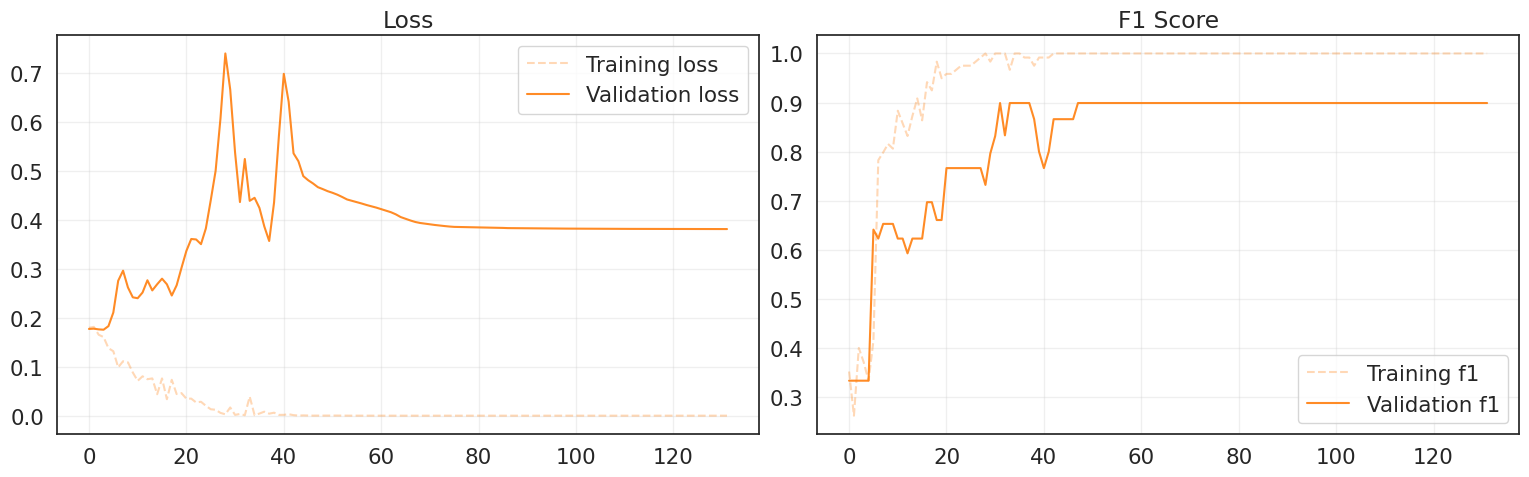

In [28]:
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.9000
Precision over the validation set: 0.9167
Recall over the validation set: 0.9000
F1 score over the validation set: 0.8990


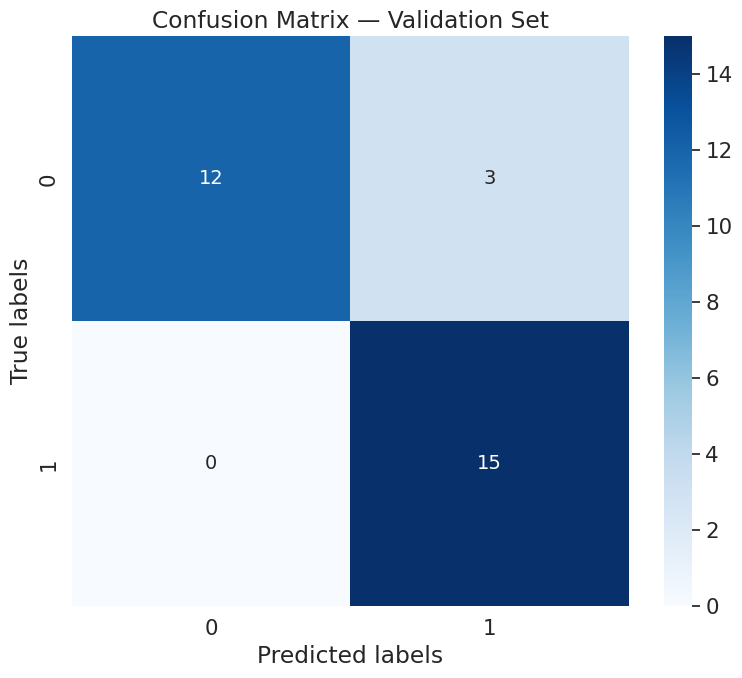

In [29]:
# Collect predictions and ground truth labels
val_preds, val_targets = [], []

with torch.no_grad():  # Disable gradient computation
    for xb_dyn, xb_static, yb in val_loader:
        # Move data to device
        xb_dyn = xb_dyn.to(device).float()
        xb_static = xb_static.to(device).float()
        yb = yb.to(device)

        # Forward pass: get model predictions
        logits = model(xb_dyn, xb_static)
        preds = (logits > 0.5).long().cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.cpu().numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')

print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualize confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## StratifiedGroupKFold and Random Splits


In [ ]:
# from sklearn.model_selection import StratifiedGroupKFold
# from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
# import numpy as np
# import torch

# N_SPLITS = 5
# N_REPEATS = 3
# SEED = 42

# all_metrics = []
# subjects = df_subjects['sample_index'].values
# labels = df_subjects['label'].values

# for repeat in range(N_REPEATS):
#     sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + repeat)

#     for fold, (train_idx, val_idx) in enumerate(sgkf.split(df_subjects, labels, groups=subjects)):
#         print(f"\n--- Repeat {repeat+1}, Fold {fold+1} ---")

#         train_users = df_subjects.iloc[train_idx]['sample_index'].values
#         val_users = df_subjects.iloc[val_idx]['sample_index'].values

#         df_train_fold = X_train[X_train['sample_index'].isin(train_users)]
#         df_val_fold = X_train[X_train['sample_index'].isin(val_users)]
#         y_train_fold = y_train[y_train['sample_index'].isin(train_users)]
#         y_val_fold = y_train[y_train['sample_index'].isin(val_users)]

#         X_train_seq, X_train_static, y_train_seq = build_sequences(df_train_fold, y_train_fold, augment=True)
#         X_val_seq, X_val_static, y_val_seq = build_sequences(df_val_fold, y_val_fold, augment=False)

#         train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
#         val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)

#         train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
#         val_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

#         model = CNN_GRU_Binary(
#           input_size_dynamic=X_train_seq.shape[-1],
#           input_size_static=X_train_static.shape[-1],
#           hidden_size=HIDDEN_SIZE,
#           num_layers=HIDDEN_LAYERS,
#           dropout_rate=DROPOUT_RATE,
#           bidirectional=False,
#           use_attention=True
#       ).to(device)

#         optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
#         scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#             optimizer, mode='max', factor=0.5, patience=15
#         )
#         scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

#         model, history = fit(
#             model, train_loader, val_loader,
#             epochs=EPOCHS,
#             criterion=criterion,
#             optimizer=optimizer,
#             scaler=scaler,
#             device=device,
#             l1_lambda=L1_LAMBDA,
#             l2_lambda=L2_LAMBDA,
#             patience=PATIENCE,
#             evaluation_metric='val_f1',
#             mode='max',
#             restore_best_weights=True,
#             verbose=10,
#             experiment_name=f"repeat{repeat+1}_fold{fold+1}",
#             base_path=BASE_PATH,
#             scheduler=scheduler  # pass scheduler to fit
#         )

#         # evaluate on validation fold
#         val_preds, val_targets = [], []
#         with torch.no_grad():
#             for xb_dyn, xb_static, yb in val_loader:
#                 xb_dyn, xb_static, yb = xb_dyn.to(device).float(), xb_static.to(device).float(), yb.to(device)
#                 logits = model(xb_dyn, xb_static)
#                 preds = logits.argmax(dim=1).cpu().numpy()
#                 val_preds.append(preds)
#                 val_targets.append(yb.cpu().numpy())

#         val_preds = np.concatenate(val_preds)
#         val_targets = np.concatenate(val_targets)

#         acc = accuracy_score(val_targets, val_preds)
#         f1 = f1_score(val_targets, val_preds, average='weighted')
#         prec = precision_score(val_targets, val_preds, average='weighted')
#         rec = recall_score(val_targets, val_preds, average='weighted')

#         all_metrics.append({'repeat': repeat+1, 'fold': fold+1,
#                             'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec})

# # summary
# metrics_array = np.array([[m['accuracy'], m['f1'], m['precision'], m['recall']] for m in all_metrics])
# mean_metrics = metrics_array.mean(axis=0)
# std_metrics = metrics_array.std(axis=0)

# print("\n=== Cross-validated results with scheduler ===")
# print(f"Accuracy: {mean_metrics[0]:.4f} ± {std_metrics[0]:.4f}")
# print(f"F1 score: {mean_metrics[1]:.4f} ± {std_metrics[1]:.4f}")
# print(f"Precision: {mean_metrics[2]:.4f} ± {std_metrics[2]:.4f}")
# print(f"Recall: {mean_metrics[3]:.4f} ± {std_metrics[3]:.4f}")


## Optuna


In [31]:
import optuna
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score

def objective(trial):
    # -----------------------
    # Hyperparameters to tune
    # -----------------------
    hidden_size = trial.suggest_int("hidden_size", 64, 256, step=32)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.05)
    bidirectional = trial.suggest_categorical("bidirectional", [True, False])
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
    l1_lambda = trial.suggest_loguniform("l1_lambda", 1e-5, 1e-2)
    l2_lambda = trial.suggest_loguniform("l2_lambda", 1e-5, 1e-2)

    window_size = trial.suggest_int("window_size", 100, 400, step=50)
    stride = trial.suggest_int("stride", 25, 200, step=25)
    batch_size = 64

    # -----------------------
    # StratifiedGroupKFold
    # -----------------------
    sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
    df_subjects = X_train[['sample_index']].drop_duplicates().merge(y_train, on='sample_index')
    f1_scores = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for train_idx, val_idx in sgkf.split(df_subjects, df_subjects['label'], groups=df_subjects['sample_index']):
        train_users = df_subjects.iloc[train_idx]['sample_index'].values
        val_users = df_subjects.iloc[val_idx]['sample_index'].values

        df_tr = X_train[X_train['sample_index'].isin(train_users)]
        df_val = X_train[X_train['sample_index'].isin(val_users)]

        y_tr = y_train[y_train['sample_index'].isin(train_users)]
        y_val = y_train[y_train['sample_index'].isin(val_users)]

        X_tr_seq, X_tr_static, y_tr_seq = build_sequences(df_tr, y_tr, window=window_size, stride=stride, augment=True)
        X_val_seq, X_val_static, y_val_seq = build_sequences(df_val, y_val, window=window_size, stride=stride, augment=False)

        train_ds = PirateDataset(X_tr_seq, X_tr_static, y_tr_seq)
        val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)

        train_loader = make_loader(train_ds, batch_size=batch_size)
        val_loader = make_loader(val_ds, batch_size=batch_size, shuffle=False)

        # -----------------------
        # Define LSTM+MLP model
        # -----------------------
        model = LSTMAttentionBinary(
            seq_input_dim=X_tr_seq.shape[2],
            static_input_dim=X_tr_static.shape[1],
            hidden_size=hidden_size,
            n_layers=num_layers,
            dropout=dropout,
            bidirectional=bidirectional
        ).to(device)

        # -----------------------
        # Loss + Optimizer
        # -----------------------
        num_pos = (y_tr_seq == 1).sum()
        num_neg = (y_tr_seq == 0).sum()
        pos_weight = torch.tensor(num_neg / (num_pos + 1e-8)).to(device)

        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=l2_lambda)
        scaler = torch.amp.GradScaler(enabled=(device.type=='cuda'))
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

        # -----------------------
        # Train model
        # -----------------------
        model, history = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=300,  # reduce for faster Optuna trials
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            l1_lambda=l1_lambda,
            l2_lambda=l2_lambda,
            patience=100,
            evaluation_metric="val_f1",
            mode='max',
            restore_best_weights=True,
            writer=None,
            verbose=0,
            experiment_name=f"optuna_trial"
        )

        # -----------------------
        # Validation F1
        # -----------------------
        val_preds, val_targets = [], []
        with torch.no_grad():
            for xb_dyn, xb_static, yb in val_loader:
                xb_dyn = xb_dyn.to(device).float()
                xb_static = xb_static.to(device).float()
                yb = yb.to(device).float()
                logits = model(xb_dyn, xb_static)
                preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
                val_preds.append(preds)
                val_targets.append(yb.cpu().numpy())

        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)
        f1_scores.append(f1_score(val_targets, val_preds))

    return np.mean(f1_scores)



In [32]:
study = optuna.create_study(
    direction="maximize",
    study_name="pirate_pain_optuna"
)

n_trials = 30
study.optimize(objective, n_trials=n_trials, n_jobs=1, show_progress_bar=True)

print("Best trial:")
trial = study.best_trial
print(f"F1 Score: {trial.value:.4f}")
print("Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-11-16 17:18:44,034] A new study created in memory with name: pirate_pain_optuna


  0%|          | 0/30 [00:00<?, ?it/s]

Training 300 epochs...
Early stopping triggered after 101 epochs.
Best model restored from epoch 1 with val_f1=0.4995
Training 300 epochs...
Early stopping triggered after 102 epochs.
Best model restored from epoch 2 with val_f1=0.4995
Training 300 epochs...
Early stopping triggered after 101 epochs.
Best model restored from epoch 1 with val_f1=0.4500
[I 2025-11-16 17:20:29,115] Trial 0 finished with value: 0.5434173669467787 and parameters: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'bidirectional': False, 'learning_rate': 0.008435674114961168, 'l1_lambda': 0.008002501754669976, 'l2_lambda': 5.0835033302116975e-05, 'window_size': 100, 'stride': 50}. Best is trial 0 with value: 0.5434173669467787.
Training 300 epochs...
Early stopping triggered after 166 epochs.
Best model restored from epoch 66 with val_f1=0.6685
Training 300 epochs...
Early stopping triggered after 205 epochs.
Best model restored from epoch 105 with val_f1=0.7624
Training 300 epochs...
Early stopping trigge

In [ ]:
# Example: best_params returned by Optuna
# best_params = study.best_trial.params

best_params = {
    'hidden_size': 224,
    'num_layers': 3,
    'dropout_rate': 0.5,
    'bidirectional': False,
    'use_attention': True,
    'learning_rate': 0.0006681049777712333,
    'l1_lambda': 2.2269656369662347e-05,
    'l2_lambda': 0.001482264917853986,
    'window_size': 100,
    'stride': 25
}

# Assign parameters from dictionary
HIDDEN_SIZE = best_params["hidden_size"]
HIDDEN_LAYERS = best_params["num_layers"]
DROPOUT_RATE = best_params["dropout_rate"]
BIDIRECTIONAL = best_params["bidirectional"]
USE_ATTENTION = best_params["use_attention"]
LEARNING_RATE = best_params["learning_rate"]
L1_LAMBDA = best_params["l1_lambda"]
L2_LAMBDA = best_params["l2_lambda"]
WINDOW_SIZE = best_params["window_size"]
STRIDE = best_params["stride"]

# DataLoader settings
BATCH_SIZE = 64
N_SPLITS = 5
N_REPEATS = 3
SEED = 42

all_metrics = []
subjects = df_subjects['sample_index'].values
labels = df_subjects['label'].values

for repeat in range(N_REPEATS):
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + repeat)

    for fold, (train_idx, val_idx) in enumerate(sgkf.split(df_subjects, labels, groups=subjects)):
        print(f"\n--- Repeat {repeat+1}, Fold {fold+1} ---")

        train_users = df_subjects.iloc[train_idx]['sample_index'].values
        val_users = df_subjects.iloc[val_idx]['sample_index'].values

        df_train_fold = X_train[X_train['sample_index'].isin(train_users)]
        df_val_fold = X_train[X_train['sample_index'].isin(val_users)]
        y_train_fold = y_train[y_train['sample_index'].isin(train_users)]
        y_val_fold = y_train[y_train['sample_index'].isin(val_users)]

        # Build sequences using optimal window and stride
        X_train_seq, X_train_static, y_train_seq = build_sequences(
            df_train_fold, y_train_fold, window=WINDOW_SIZE, stride=STRIDE, augment=True
        )
        X_val_seq, X_val_static, y_val_seq = build_sequences(
            df_val_fold, y_val_fold, window=WINDOW_SIZE, stride=STRIDE, augment=False
        )

        train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
        val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)

        train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

        # Initialize model with best parameters
        model = CNN_GRU_Binary(
            input_size_dynamic=X_train_seq.shape[-1],
            input_size_static=X_train_static.shape[-1],
            hidden_size=HIDDEN_SIZE,
            num_layers=HIDDEN_LAYERS,
            dropout_rate=DROPOUT_RATE,
            bidirectional=BIDIRECTIONAL,
            use_attention=USE_ATTENTION
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=15
        )
        scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

        model, history = fit(
            model, train_loader, val_loader,
            epochs=EPOCHS,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            l1_lambda=L1_LAMBDA,
            l2_lambda=L2_LAMBDA,
            patience=PATIENCE,
            evaluation_metric='val_f1',
            mode='max',
            restore_best_weights=True,
            verbose=10,
            experiment_name=f"repeat{repeat+1}_fold{fold+1}",
            base_path=BASE_PATH,
            scheduler=scheduler
        )

        # Evaluate on validation fold
        val_preds, val_targets = [], []
        with torch.no_grad():
            for xb_dyn, xb_static, yb in val_loader:
                xb_dyn, xb_static, yb = xb_dyn.to(device).float(), xb_static.to(device).float(), yb.to(device)
                logits = model(xb_dyn, xb_static)
                preds = logits.argmax(dim=1).cpu().numpy()
                val_preds.append(preds)
                val_targets.append(yb.cpu().numpy())

        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)

        acc = accuracy_score(val_targets, val_preds)
        f1 = f1_score(val_targets, val_preds, average='weighted')
        prec = precision_score(val_targets, val_preds, average='weighted')
        rec = recall_score(val_targets, val_preds, average='weighted')

        all_metrics.append({
            'repeat': repeat+1, 'fold': fold+1,
            'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec
        })

# Summary statistics
metrics_array = np.array([[m['accuracy'], m['f1'], m['precision'], m['recall']] for m in all_metrics])
mean_metrics = metrics_array.mean(axis=0)
std_metrics = metrics_array.std(axis=0)

print("\n=== Cross-validated results with Optuna best_params ===")
print(f"Accuracy: {mean_metrics[0]:.4f} ± {std_metrics[0]:.4f}")
print(f"F1 score: {mean_metrics[1]:.4f} ± {std_metrics[1]:.4f}")
print(f"Precision: {mean_metrics[2]:.4f} ± {std_metrics[2]:.4f}")
print(f"Recall: {mean_metrics[3]:.4f} ± {std_metrics[3]:.4f}")


--- Repeat 1, Fold 1 ---
Training 500 epochs...
Epoch   1/500 | Train: Loss=1.3141, F1=0.5954 | Val: Loss=0.6928, F1=0.4391
Epoch  10/500 | Train: Loss=0.4302, F1=0.9850 | Val: Loss=0.5793, F1=0.8643
Epoch  20/500 | Train: Loss=0.3572, F1=0.9817 | Val: Loss=0.6055, F1=0.8200
Epoch  30/500 | Train: Loss=0.2913, F1=1.0000 | Val: Loss=0.7069, F1=0.8035
Epoch  40/500 | Train: Loss=0.2877, F1=0.9933 | Val: Loss=0.6892, F1=0.8265
Epoch  50/500 | Train: Loss=0.2659, F1=0.9967 | Val: Loss=0.6895, F1=0.8213
Epoch  60/500 | Train: Loss=0.2564, F1=1.0000 | Val: Loss=0.5487, F1=0.8643
Epoch  70/500 | Train: Loss=0.2541, F1=0.9983 | Val: Loss=0.5618, F1=0.8643
Epoch  80/500 | Train: Loss=0.2469, F1=1.0000 | Val: Loss=0.5132, F1=0.8713
Epoch  90/500 | Train: Loss=0.2444, F1=1.0000 | Val: Loss=0.5460, F1=0.8643
Epoch 100/500 | Train: Loss=0.2431, F1=1.0000 | Val: Loss=0.5527, F1=0.8643
Early stopping triggered after 107 epochs.
Best model restored from epoch 7 with val_f1=0.9266

--- Repeat 1, Fold 